In [1]:
import numpy as np #handles numerical operations
import pandas as pd #used to work with tables/datasets

import io #helps with input/output operations

from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
#StandardScaler scales using the formula (x-mu)/sigma

from sklearn.feature_selection import VarianceThreshold #removes features that barely change.

from sklearn.model_selection import train_test_split
#Training data teaches the model and Testing data checks how well the model performs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"
columns = [
    'SpMax_L', 'J_Dz_e', 'nHM', 'F01_N', 'F04_C',
    'NssssC', 'nCb', 'C', 'nCp', 'nO',
    'F03_N', 'SdssC', 'HyWi_B', 'LOC', 'SM6_L',
    'F03_C', 'Me', 'Mi', 'nN', 'nArNO2',
    'nCRX3', 'SpPosA_B', 'nCIR', 'B01_C', 'B03_C',
    'N', 'SpMax_A', 'Psi_i_1d', 'B04_C', 'SdO',
    'TI2_L', 'nCrt', 'Crt', 'Is_biodegradable'
]
data = pd.read_csv(url, sep=';', header=None, names=columns)
data.head(1055)

,,,,,,,,SpMax_L,J_Dz_e,nHM,F01_N,F04_C,NssssC,nCb,C,nCp,nO,...,B03_C,N,SpMax_A,Psi_i_1d,B04_C,SdO,TI2_L,nCrt,Crt,Is_biodegradable
3.919,2.6909,0,0,0,0,0,31.4,2,0,0,0.000,3.106,2.550,9.002,0,0.960,1.142,...,0,0,0,2.949,1.591,0,7.253,0,0,RB
4.170,2.1144,0,0,0,0,0,30.8,1,1,0,0.000,2.461,1.393,8.723,1,0.989,1.144,...,0,0,0,3.315,1.967,0,7.257,0,0,RB
3.932,3.2512,0,0,0,0,0,26.7,2,4,0,0.000,3.279,2.585,9.110,0,1.009,1.152,...,0,0,1,3.076,2.417,0,7.601,0,0,RB
3.000,2.7098,0,0,0,0,0,20.0,0,2,0,0.000,2.100,0.918,6.594,0,1.108,1.167,...,0,0,1,3.046,5.000,0,6.690,0,0,RB
4.236,3.3944,0,0,0,0,0,29.4,2,4,0,-0.271,3.449,2.753,9.528,2,1.004,1.147,...,0,0,0,3.351,2.405,0,8.003,0,0,RB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5.431,2.8955,0,0,0,2,0,32.1,4,1,1,0.374,3.233,0.832,10.681,2,0.982,1.144,...,0,6,1,3.573,2.242,1,8.088,0,0,NRB
5.287,3.3732,0,0,9,0,0,35.3,0,9,9,-5.256,4.319,2.346,11.029,21,1.043,1.140,...,0,3,0,3.787,3.083,3,9.278,0,0,NRB
4.869,1.7670,0,1,9,0,5,44.4,0,4,14,-0.391,4.435,1.073,11.072,9,1.016,1.123,...,4,13,0,3.848,2.576,5,9.537,1,0,NRB
5.158,1.6914,2,0,36,0,9,56.1,0,0,44,0.000,4.902,0.257,11.817,0,1.007,1.093,...,1,16,0,5.808,2.055,8,11.055,0,1,NRB


In [3]:
# Remove duplicate rows
data = data.drop_duplicates()

# Remove missing values
data = data.dropna()

# Split features and target
X = data.drop('Is_biodegradable', axis=1) #Contains all input features
y = data['Is_biodegradable'] #Contains target labels

encoder = LabelEncoder() 
#LabelEncoder converts labels into numbers(binary)

y = encoder.fit_transform(y)


selector = VarianceThreshold(threshold=0.01) #Removes low variance columns

X_var = selector.fit_transform(X) #Applies variance filtering

selected_columns = X.columns[selector.get_support()] #Gets names of the remaining useful columns

X = pd.DataFrame(X_var, columns=selected_columns) #Converts the data back into the dataset


corr_matrix = X.corr().abs() #If two features contain almost identical information, we remove one

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

X = X.drop(columns=to_drop)

scaler = RobustScaler() #RobustScaler is used when outliers are present, it uses median to scale the data

X_scaled = scaler.fit_transform(X)

print("Final shape:", X_scaled.shape)

Final shape: (1052, 30)


Accuracy: 0.8530805687203792


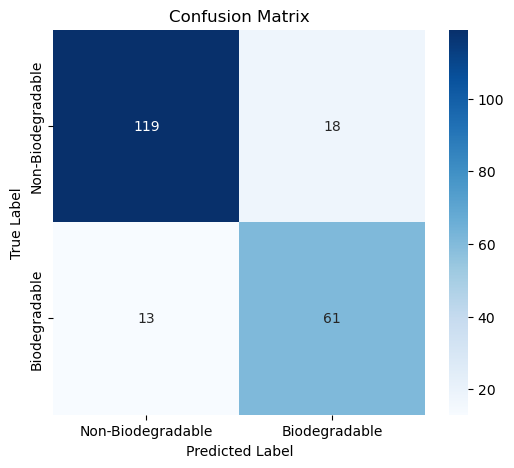


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       137
           1       0.77      0.82      0.80        74

    accuracy                           0.85       211
   macro avg       0.84      0.85      0.84       211
weighted avg       0.86      0.85      0.85       211



In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# Create Logistic Regression model
model = LogisticRegression(max_iter=5000)


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)


# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
#Accuracy is correct predictions over total predictions

# Create confusion matrix: [TP,TN;FP,FN]
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Biodegradable', 'Biodegradable'],
    yticklabels=['Non-Biodegradable', 'Biodegradable']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()


# Detailed Classification Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Precision=TP/(TP+FP)how many truly were biodegradable?
#Recall=TP/(TP+FN) how many did the model successfully detect
#F1-score balances precision and recall. F1=2(Precision*Recall)/(Precision+Recall)
#Support is the number of true occurrences of each class.

Accuracy: 0.8625592417061612


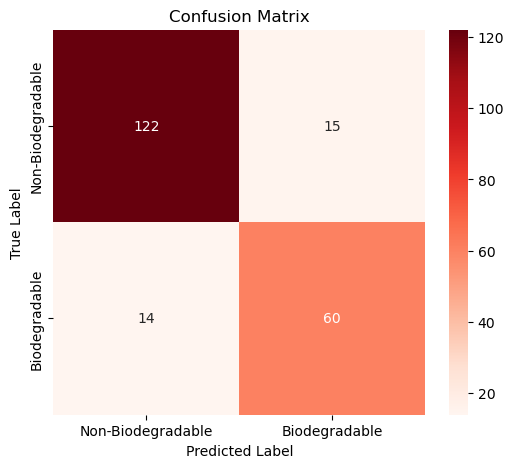


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       137
           1       0.80      0.81      0.81        74

    accuracy                           0.86       211
   macro avg       0.85      0.85      0.85       211
weighted avg       0.86      0.86      0.86       211



In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

#Creates 100 decision trees. Each tree votes. Final prediction is based on majority voting.


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)


# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Non-Biodegradable', 'Biodegradable'],
    yticklabels=['Non-Biodegradable', 'Biodegradable']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8246445497630331


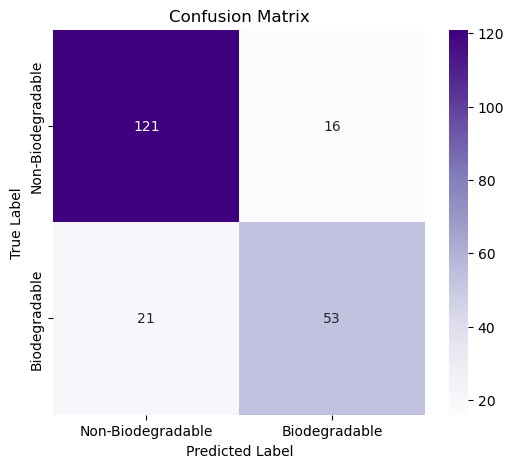


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       137
           1       0.77      0.72      0.74        74

    accuracy                           0.82       211
   macro avg       0.81      0.80      0.80       211
weighted avg       0.82      0.82      0.82       211



In [6]:
# Create SVM model
model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)
#RBF = Radial Basis Function. Allows non-linear classification. This is important as chemical data is rarely linearly separable
#Support Vector Machine tries to find the best boundary separating classes.

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Non-Biodegradable', 'Biodegradable'],
    yticklabels=['Non-Biodegradable', 'Biodegradable']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))